<a href="https://colab.research.google.com/github/lavanyasangeeth22/time-series-forecasting-xgboost/blob/main/temperature_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import mean_squared_error

# Configure visual style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

In [21]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"
print("Loading dataset...")

# Read dataset and parse dates
df = pd.read_csv(url)
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')
df.columns = ['Temp']

# Clean non-numeric values and handle missing data
df['Temp'] = pd.to_numeric(df['Temp'], errors='coerce')
df = df.dropna().sort_index()

df.head()

Loading dataset...


,Temp
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8


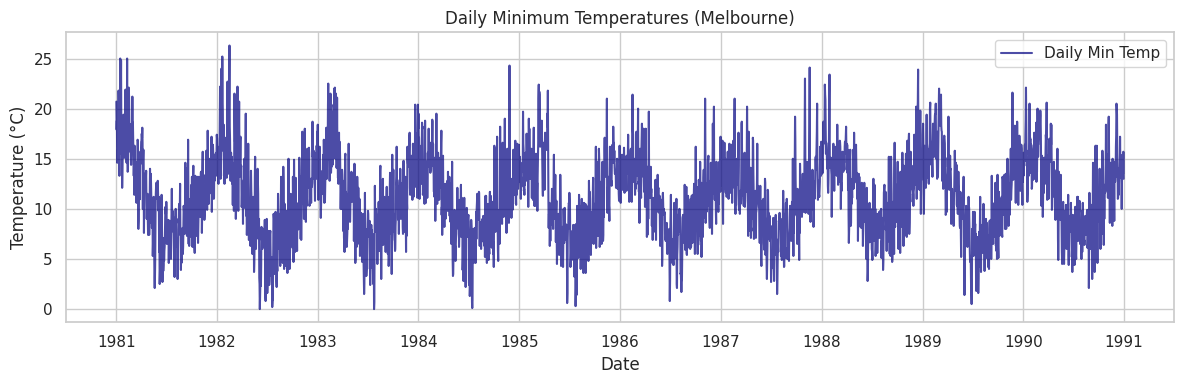

In [22]:
plt.figure(figsize=(12, 4))
plt.plot(df.index, df['Temp'], color='navy', alpha=0.7, label='Daily Min Temp')
plt.title('Daily Minimum Temperatures (Melbourne)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
def create_features(dataframe):
    df_feat = dataframe.copy()

    # Calendar features
    df_feat['dayofweek'] = df_feat.index.dayofweek
    df_feat['quarter'] = df_feat.index.quarter
    df_feat['month'] = df_feat.index.month
    df_feat['year'] = df_feat.index.year
    df_feat['dayofyear'] = df_feat.index.dayofyear
    df_feat['dayofmonth'] = df_feat.index.day

    # Lag & Rolling features (improves tracking of short-term weather trends)
    df_feat['lag_1'] = df_feat['Temp'].shift(1)
    df_feat['lag_7'] = df_feat['Temp'].shift(7)
    df_feat['rolling_mean_7'] = df_feat['Temp'].shift(1).rolling(window=7).mean()

    return df_feat

df_features = create_features(df)
# Drop NaN rows generated by shifting/rolling
df_features = df_features.dropna()
df_features.head()

,Temp,dayofweek,quarter,month,year,dayofyear,dayofmonth,lag_1,lag_7,rolling_mean_7
Date,,,,,,,,,,
1981-01-08,17.4,3,1,1,1981,8,8,15.8,20.7,17.057143
1981-01-09,21.8,4,1,1,1981,9,9,17.4,17.9,16.585714
1981-01-10,20.0,5,1,1,1981,10,10,21.8,18.8,17.142857
1981-01-11,16.2,6,1,1,1981,11,11,20.0,14.6,17.314286
1981-01-12,13.3,0,1,1,1981,12,12,16.2,15.8,17.542857


In [24]:
split_date = '1988-01-01'

train = df_features.loc[df_features.index < split_date]
test = df_features.loc[df_features.index >= split_date]

FEATURES = ['dayofweek', 'quarter', 'month', 'year', 'dayofyear', 'dayofmonth', 'lag_1', 'lag_7', 'rolling_mean_7']
TARGET = 'Temp'

X_train, y_train = train[FEATURES], train[TARGET]
X_test, y_test = test[FEATURES], test[TARGET]

print(f"Training set: {len(train)} rows | Testing set: {len(test)} rows")

Training set: 2548 rows | Testing set: 1095 rows


In [25]:
reg = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=5,
    early_stopping_rounds=50,
    random_state=42
)

reg.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=100
)

[0]	validation_0-rmse:4.05331	validation_1-rmse:4.02667
[100]	validation_0-rmse:2.60558	validation_1-rmse:2.63360
[200]	validation_0-rmse:2.24242	validation_1-rmse:2.35682
[300]	validation_0-rmse:2.11925	validation_1-rmse:2.32160
[400]	validation_0-rmse:2.05192	validation_1-rmse:2.31474
[439]	validation_0-rmse:2.03362	validation_1-rmse:2.31533


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)


Root Mean Squared Error (RMSE): 2.3141


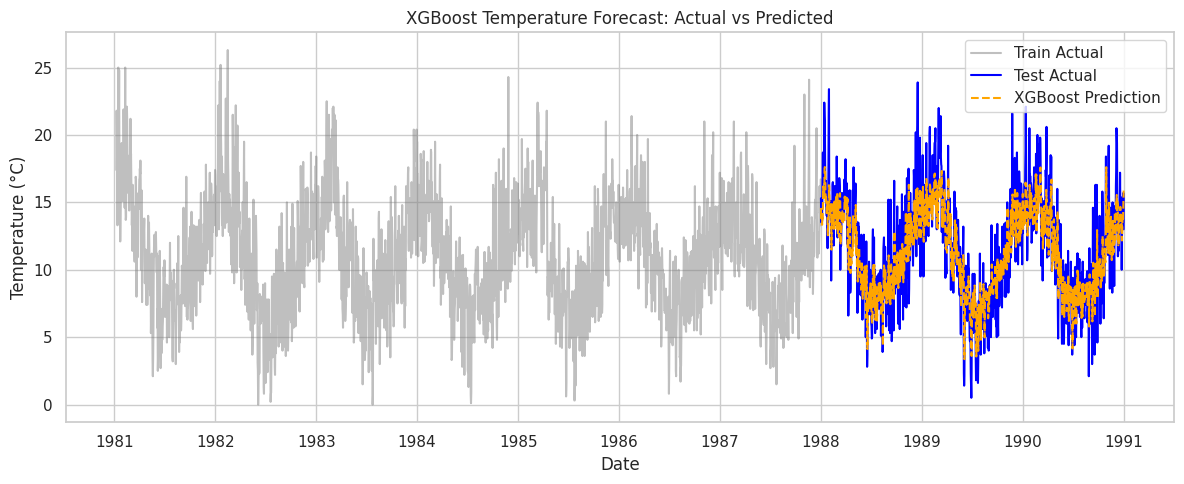

In [26]:
# Predict on test data
test = test.copy()
test['Prediction'] = reg.predict(X_test)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(test[TARGET], test['Prediction']))
print(f"\nRoot Mean Squared Error (RMSE): {rmse:.4f}")

# Plot actual vs predicted values
plt.figure(figsize=(12, 5))
plt.plot(train.index, train[TARGET], label='Train Actual', color='gray', alpha=0.5)
plt.plot(test.index, test[TARGET], label='Test Actual', color='blue')
plt.plot(test.index, test['Prediction'], label='XGBoost Prediction', color='orange', linestyle='--')
plt.title('XGBoost Temperature Forecast: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()

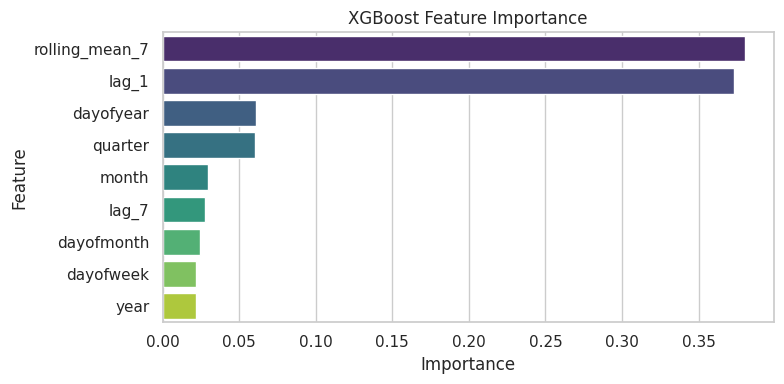

In [27]:
importance_df = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': reg.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature',
    hue='Feature',
    palette='viridis',
    legend=False
)
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()